# Exercises XP: Guided Student Notebook

## Daily Challenge: Building Your First Neural Network on the MNIST Dataset


### 👩‍🏫 👩🏿‍🏫 What You’ll learn
How to load and preprocess the MNIST dataset
How to build and train a simple neural network for digit classification
How to evaluate a neural network’s performance using accuracy metrics
How to optimize model performance through hyperparameter tuning


### 🛠️ What you will create
A fully connected neural network for recognizing handwritten digits
A training pipeline to learn from the MNIST dataset
A visualization of the model’s performance on test images
A basic hyperparameter tuning experiment


### What You Need to Do
**1. Load and Preprocess the MNIST Dataset**

Load the MNIST dataset using TensorFlow/Keras
Normalize the image pixel values to be between 0 and 1
Convert labels into one-hot encoded format
Split the dataset into training and test sets
Display sample images with their corresponding labels

**2. Build a Fully Connected Neural Network**

Define a sequential model using Keras
Flatten the 28x28 input images into a single vector
Add two hidden layers with ReLU activation
Add an output layer with Softmax activation for multi-class classification
Compile the model using categorical cross-entropy as the loss function and accuracy as the evaluation metric

**3. Train the Neural Network**

Fit the model to the training data for 10 epochs
Use a validation set to track performance during training
Observe the loss and accuracy trends over the epochs

**4. Evaluate the Model’s Performance**

Compute accuracy on the test dataset
Display a confusion matrix for misclassified digits
Identify which digits the model struggles with the most

# Pipeline
⬜ Load data
⬜ Normalize
⬜ One-hot encoding
⬜ Display images
⬜ Build model
⬜ Compile model
⬜ Train model
⬜ Validation
⬜ Evaluate
⬜ Confusion matrix
⬜ Hyperparameter tuning

In [1]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical #for One-Hot Encoding.
from tensorflow.keras.datasets import mnist # mnist - a dataset from Tensorflow library, contains 70000 images of handwritten digits

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0 #normalizattion
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [2]:
# To-Do: one-hot encode labels y_train and y_test using to_categorical
# Hints: use to_categorical
y_train_oh = to_categorical(y_train)
y_test_oh = to_categorical(y_test)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)


Labels one-hot: (60000, 10) (10000, 10)


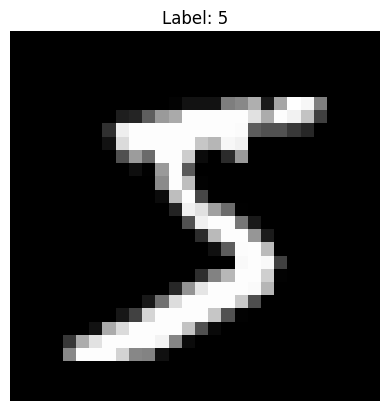

In [3]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

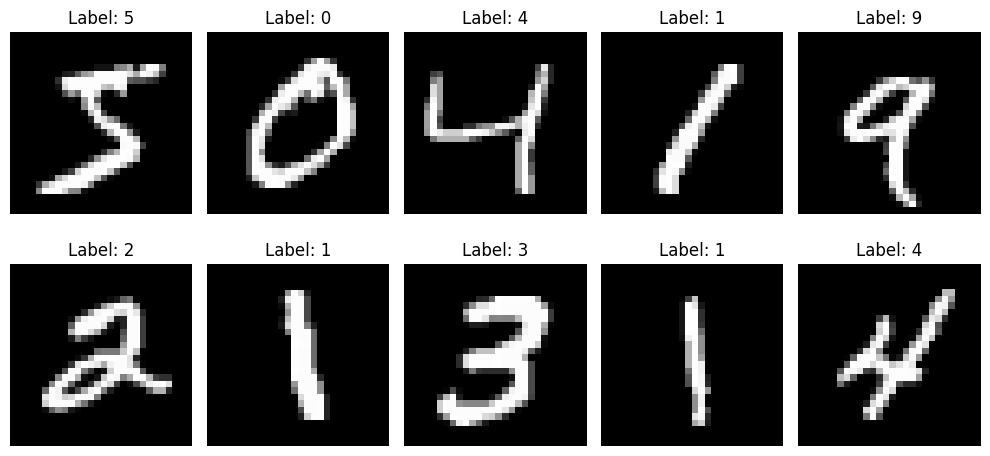

In [4]:
# Show the first 10 images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Build a Fully Connected Neural Network

In [5]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation

In [6]:
# To-Do: compile the model with adam (oprimizer) (to calculate how update weights and bias to minimize loss), categorical_crossentropy (to measure loss), and accuracy (metric)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Training using a validation set to track performance during training

In [7]:
# To-Do: train then evaluate
history = model.fit(
    x_train,
    y_train_oh,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)
test_loss, test_acc = model.evaluate(
    x_test,
    y_test_oh
)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9246 - loss: 0.2565 - val_accuracy: 0.9673 - val_loss: 0.1126
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9687 - loss: 0.1036 - val_accuracy: 0.9702 - val_loss: 0.1014
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9771 - loss: 0.0735 - val_accuracy: 0.9765 - val_loss: 0.0808
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9831 - loss: 0.0539 - val_accuracy: 0.9763 - val_loss: 0.0796
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9861 - loss: 0.0446 - val_accuracy: 0.9772 - val_loss: 0.0849
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9748 - loss: 0.0910
{'test_loss': 0.09104061871767044, 'test_acc': 0.9747999906539917}


## Get predictions and build the confusion matrix

In [8]:
# Get predicted probabilities for each class (0-9)
y_prob = model.predict(x_test)

# Convert probabilities to predicted class labels
# argmax returns the index of the highest probability for each image
y_pred = np.argmax(y_prob, axis=1)

from sklearn.metrics import confusion_matrix

# Build a confusion matrix using true and predicted labels
cm = confusion_matrix(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


# Visualize the confusion matrix

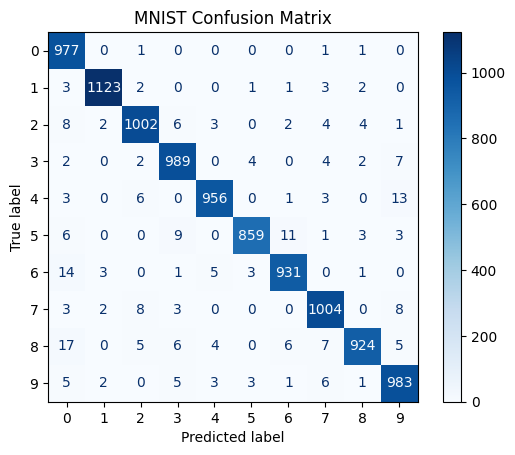

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a confusion matrix visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot the confusion matrix
disp.plot(cmap="Blues")

# Add a title
plt.title("MNIST Confusion Matrix")

# Display the plot
plt.show()

Confusion Matrix Analysis

The confusion matrix shows that most predictions are correct because the highest values are on the diagonal. The model most frequently confuses digits 4 and 9, 7 and 2, and 6 and 0. These digits have similar handwritten shapes, making them harder to distinguish. Overall, the model achieves high classification accuracy with relatively few misclassifications.

# Hyperparameter tuning (new model with 10 epochs)

In [10]:
from tensorflow.keras import models, layers

# Create a new model for the hyperparameter tuning experiment
model_10 = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Display the model architecture
model_10.summary()

# Compile the model
model_10.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model for 10 epochs
history_10 = model_10.fit(
    x_train,
    y_train_oh,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Evaluate the model on the test set
test_loss_10, test_acc_10 = model_10.evaluate(
    x_test,
    y_test_oh
)

# Print the evaluation results
print({"test_loss": float(test_loss_10), "test_acc": float(test_acc_10)})

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9243 - loss: 0.2607 - val_accuracy: 0.9707 - val_loss: 0.1021
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9666 - loss: 0.1062 - val_accuracy: 0.9732 - val_loss: 0.0942
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9770 - loss: 0.0729 - val_accuracy: 0.9760 - val_loss: 0.0848
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9826 - loss: 0.0554 - val_accuracy: 0.9770 - val_loss: 0.0808
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9861 - loss: 0.0424 - val_accuracy: 0.9728 - val_loss: 0.0906
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9879 - loss: 0.0362 - val_accuracy: 0.9767 - val_loss: 0.0901
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9903 - loss: 0.0300 - val_accuracy: 0.9778 - val_loss: 0.0852
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9907 - loss: 0.0259 -

| Metric              | 5 epochs | 10 epochs |
| ------------------- | -------: | --------: |
| Training accuracy   |   98.54% |    99.33% |
| Validation accuracy |   97.88% |    97.77% |
| Test accuracy       |   97.71% |    97.73% |
| Test loss           |   0.0774 |    0.0916 |


# Conclusion

I increased the number of epochs from 5 to 10. The training accuracy improved from 98.54% to 99.33%, but the validation and test accuracy remained almost unchanged. The test loss increased slightly. This indicates that additional epochs did not significantly improve the model's performance on unseen data and may have started to introduce slight overfitting.